# Project 3 - Eddie Vargas

This section of code imports the "pandas" package using the import function.
Using numpy for calculations and Matplotlib
for creating plots. 

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style('whitegrid')
sns.set_palette('deep')

Loads NHTS data and removes missing values to ensure accurate plots

This section loads the NHTS dataset into the Python environment using the pd.read_csv() function. The dropna() function is then used to remove rows with missing values in important variables so the final plots are based on complete data.

In [3]:
# Load data
nhts_data = pd.read_csv('NHTS.csv')
# Check missing values 
# nhts_data.isnull().sum()

nhts_data = nhts_data.dropna()

This section loads the NHTS dataset into the Python environment using the pd.read_csv() function. The dropna() function is then used to remove rows with missing values in important variables so the final plots are based on complete data.

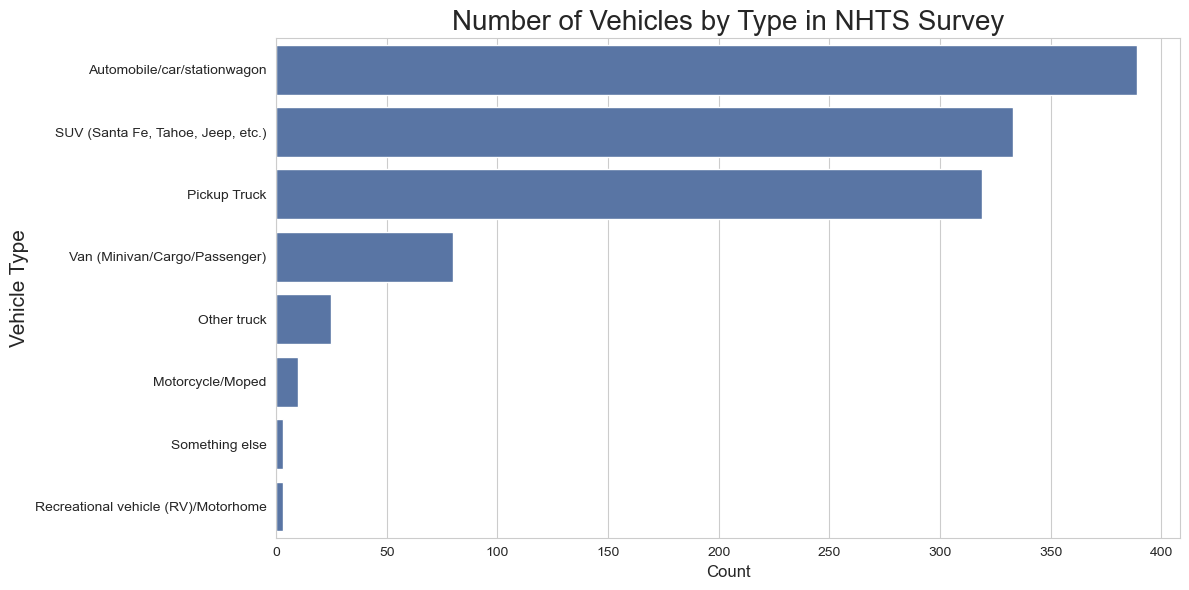

In [4]:
# Bar chart: Vehicle type distribution
plt.figure(figsize=(12, 6))

sns.countplot(
    data=nhts_data,
    y='vehicle_type',
    order=nhts_data['vehicle_type'].value_counts().index
)

plt.xlabel('Count', fontsize=12)
plt.ylabel('Vehicle Type', fontsize=15)
plt.title('Number of Vehicles by Type in NHTS Survey', fontsize=20)

plt.tight_layout()
plt.show()

This code creates a bar chart showing the number of vehicles in each vehicle type category. The sns.countplot() function is used to count the frequency of each category, and the value_counts() function is used to order the categories from most common to least common. The labeling functions are used to make the graph clear and readable.

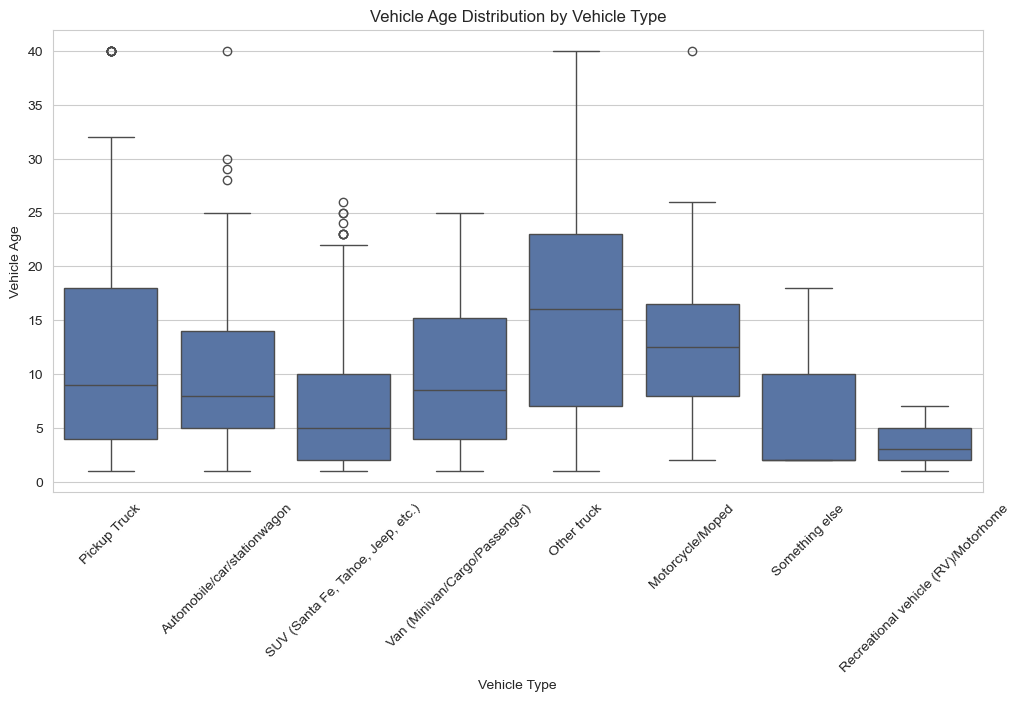

In [5]:
# Boxplot: Vehicle age by vehicle type
plt.figure(figsize=(12, 6))

sns.boxplot(x='vehicle_type', y='vehicle_age', data=nhts_data)

plt.xlabel('Vehicle Type')
plt.ylabel('Vehicle Age')
plt.title('Vehicle Age Distribution by Vehicle Type')

plt.xticks(rotation=45)
plt.show()

This section creates a boxplot to compare vehicle age across vehicle type categories. The sns.boxplot() function is used to show the distribution, median, spread, and possible outliers for vehicle age in each category. The axis labels and title are added to make the plot understandable to the reader.

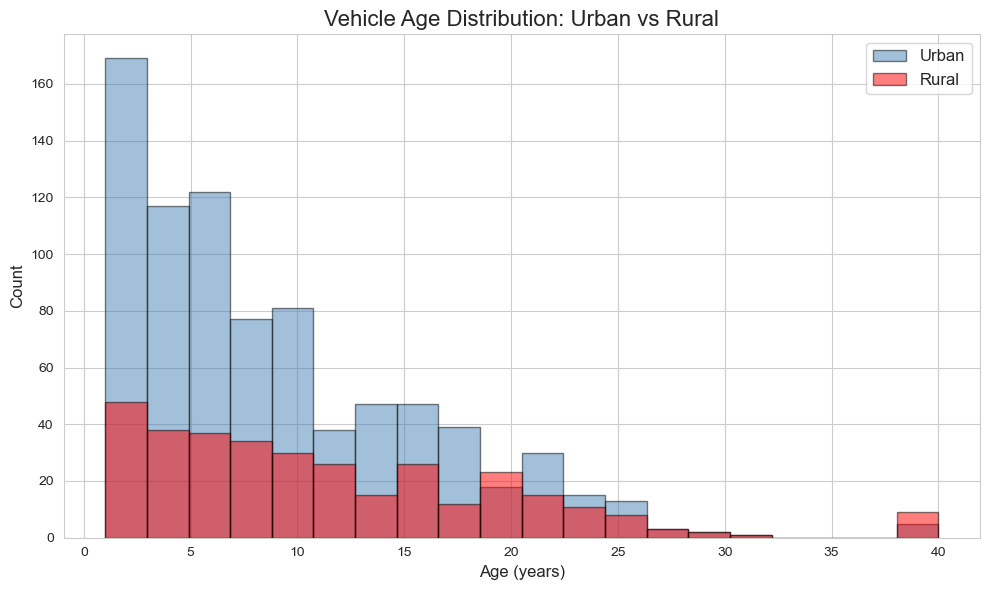

In [6]:
# Histogram: Vehicle age (Urban vs Rural)
plt.figure(figsize=(10, 6))

urban_ages = nhts_data[nhts_data['household_location'] == 'Urban']['vehicle_age']
plt.hist(
    urban_ages,
    bins=20,
    alpha=0.5,
    label='Urban',
    color='steelblue',
    edgecolor='black'
)

rural_ages = nhts_data[nhts_data['household_location'] == 'Rural']['vehicle_age']
plt.hist(
    rural_ages,
    bins=20,
    alpha=0.5,
    label='Rural',
    color='red',
    edgecolor='black'
)

plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Vehicle Age Distribution: Urban vs Rural', fontsize=16)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

This line of code is very important because loads
the NGSIM dataset, that contains time series vehicle
trajectory data used for analysing driving behavior and simulation.

In [7]:
# Load the NGSIM dataset
ngsim_data = pd.read_csv('NGSIM.csv')


This section selects one vehicle trajectory pair from the NGSIM dataset and prepares the variables used in the time-series figure. The code filters the dataset using the selected trajectory number and calculates the gap distance between the leader and follower vehicles. The plt.subplots() function is then used to create a 2 by 2 figure layout.

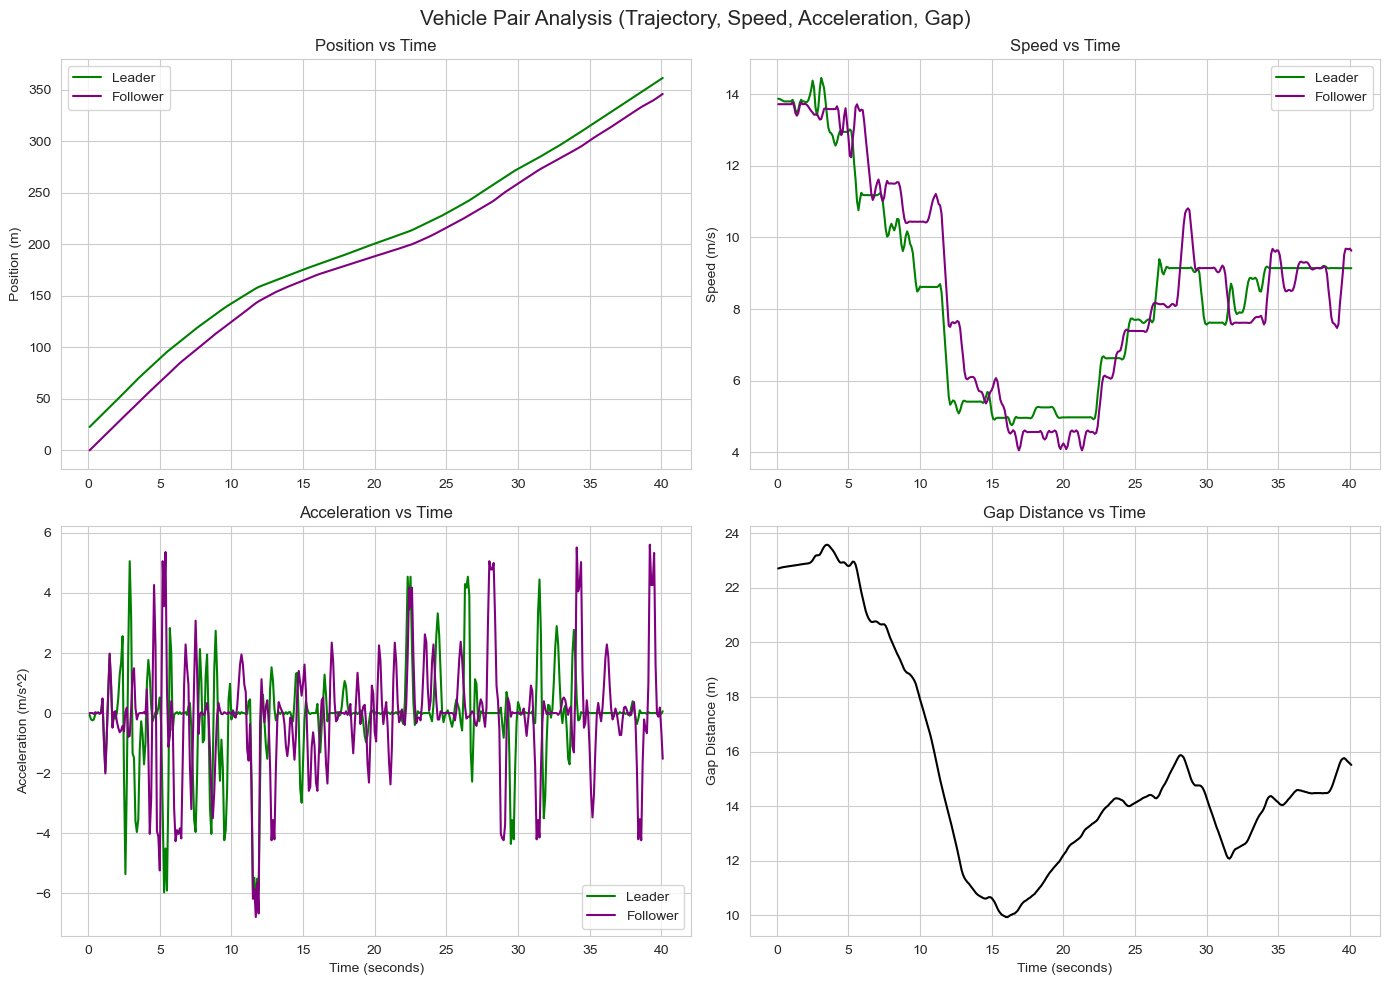

In [8]:
# Time-series: Combined analysis for one vehicle pair
trajectory_number = 9
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number]

time = data_subset['Time'].values
gap_distance = data_subset['leader_position(m)'] - data_subset['follower_position(m)']

fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Position
axes[0,0].plot(time, data_subset['leader_position(m)'], label='Leader', color='green')
axes[0,0].plot(time, data_subset['follower_position(m)'], label='Follower', color='purple')
axes[0,0].set_ylabel('Position (m)')
axes[0,0].set_title('Position vs Time')
axes[0,0].legend()

# Speed
axes[0,1].plot(time, data_subset['leader_speed(m/s)'], label='Leader', color='green')
axes[0,1].plot(time, data_subset['follower_speed(m/s)'], label='Follower', color='purple')
axes[0,1].set_ylabel('Speed (m/s)')
axes[0,1].set_title('Speed vs Time')
axes[0,1].legend()

# Acceleration
axes[1,0].plot(time, data_subset['leader_acc(m/s^2)'], label='Leader', color='green')
axes[1,0].plot(time, data_subset['follower_acc(m/s^2)'], label='Follower', color='purple')
axes[1,0].set_ylabel('Acceleration (m/s^2)')
axes[1,0].set_xlabel('Time (seconds)')
axes[1,0].set_title('Acceleration vs Time')
axes[1,0].legend()

# Gap
axes[1,1].plot(time, gap_distance, color='black')
axes[1,1].set_ylabel('Gap Distance (m)')
axes[1,1].set_xlabel('Time (seconds)')
axes[1,1].set_title('Gap Distance vs Time')

plt.suptitle('Vehicle Pair Analysis (Trajectory, Speed, Acceleration, Gap)', fontsize=15)
plt.tight_layout()

plt.show()

This section defines the Intelligent Driver Model acceleration function. The function calculates follower acceleration using the current speed, spacing, relative speed, and driver behavior parameters. The conditional statements are included to prevent division by zero during the calculation.

In [9]:
# IDM acceleration function
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):

    # Avoid division by zero
    if s <= 0:
        s = 0.1
    if v0 <= 0:
        v0 = 0.1

    # Desired minimum gap
    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))
    s_star = max(s_star, s0)

    # IDM acceleration equation
    acceleration = a * (1 - (v / v0)**delta - (s_star / s)**2)

    return acceleration

This code prepares the NGSIM data for the IDM simulation. A specific vehicle pair is selected, and the leader’s time, position, and speed data are extracted. The time step dt is also defined for the simulation updates.

In [10]:
# IDM simulation setup
trajectory_number = 4
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)

time_data = data_subset['Time']
leader_position = data_subset['leader_position(m)']
leader_speed = data_subset['leader_speed(m/s)']

dt = 0.1  # time step (s)

This part of the code defines the IDM parameters 
and initializes arrays to store simulated position, speed, and acceleration, starting from the real followers initial state.

In [11]:
# IDM parameters
v0 = 30      # desired velocity (m/s)
s0 = 2       # minimum spacing (m)
T = 1.5      # desired time headway (s)
a_param = 1.0
b = 1.5
delta = 4

# Initialize simulation arrays
n_steps = len(time_data)
sim_position = np.zeros(n_steps)
sim_speed = np.zeros(n_steps)
sim_acc = np.zeros(n_steps)

# Initial follower conditions
sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]

This section defines the IDM parameters and initializes arrays to store the simulated position, speed, and acceleration results. The simulation begins with the real follower vehicle’s initial position and speed so the comparison with the measured data is consistent.


In [12]:
# Run the IDM simulation
for i in range(n_steps - 1):

    gap = max(leader_position[i] - sim_position[i], 0.1)
    delta_v = sim_speed[i] - leader_speed[i]

    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)

    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0)
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt

This plot compares the real and simulated acceleration values. It is used to validate whether the IDM model captures the acceleration behavior of the follower vehicle, which is specifically required in the project prompt.

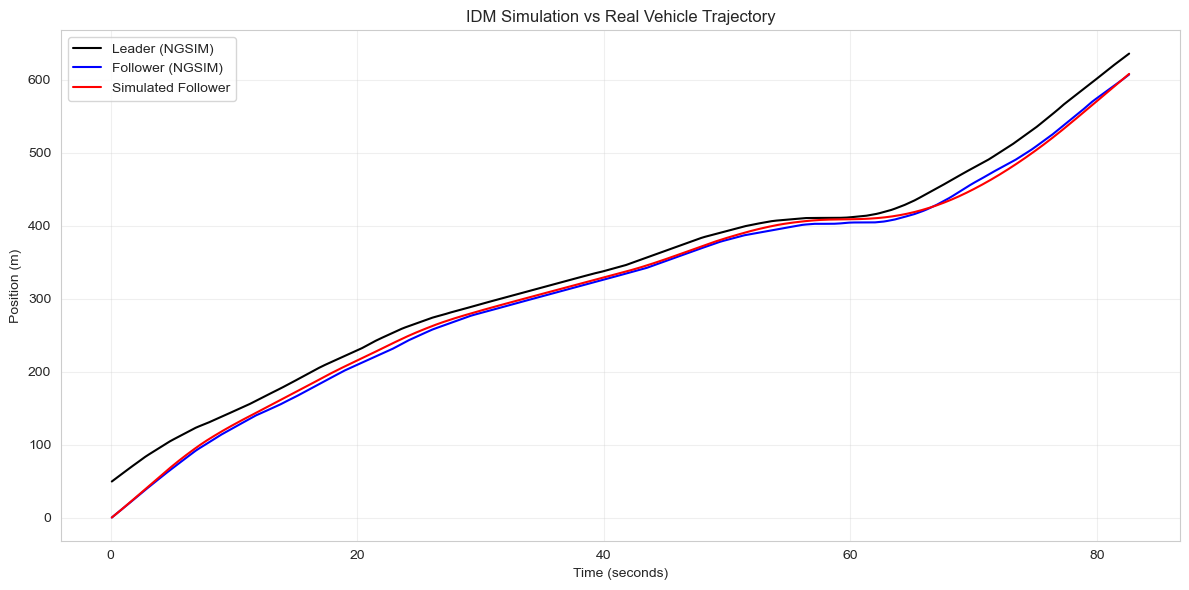

In [13]:
# IDM validation: Position vs Time
plt.figure(figsize=(12,6))

plt.plot(time_data, leader_position, label='Leader (NGSIM)', color='black')
plt.plot(time_data, data_subset['follower_position(m)'], label='Follower (NGSIM)', color='blue')
plt.plot(time_data, sim_position, label='Simulated Follower', color='red')

plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.title('IDM Simulation vs Real Vehicle Trajectory')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

This section of code creates a time-series plot comparing the acceleration of the leader vehicle, the real follower vehicle from the NGSIM dataset, and the simulated follower generated using the IDM model. The plt.plot() function is used to display each acceleration profile over time, while labels, title, and legend are added to clearly distinguish each line. This plot is used to evaluate how well the IDM model reproduces the acceleration behavior of the follower vehicle.

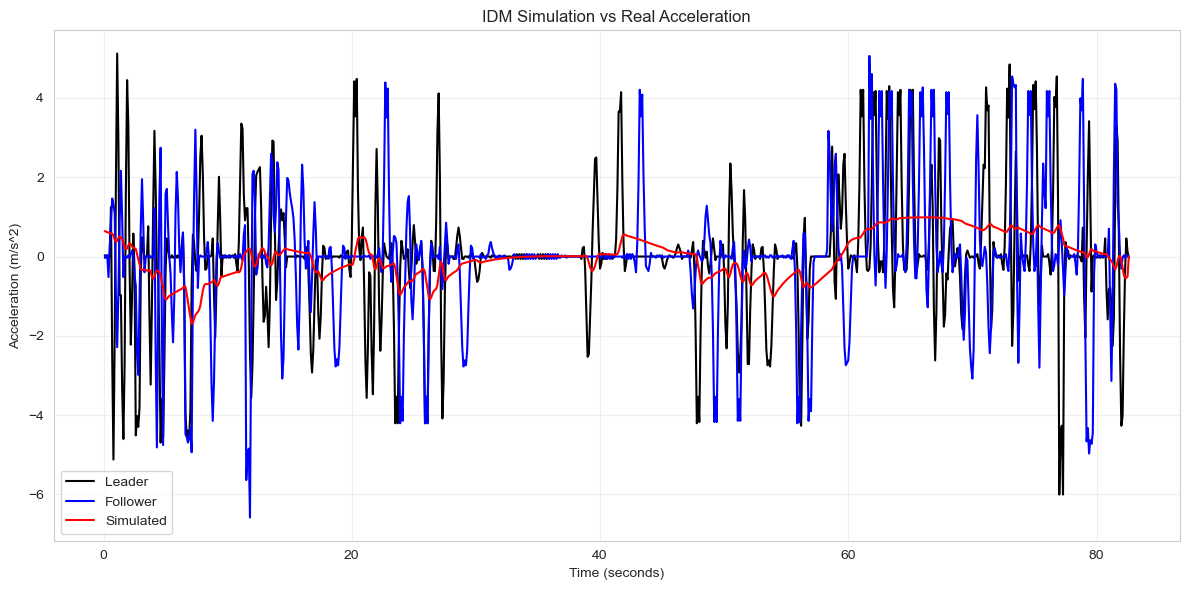

In [15]:
# IDM validation: Acceleration
plt.figure(figsize=(12,6))

plt.plot(time_data, data_subset['leader_acc(m/s^2)'], label='Leader', color='black')
plt.plot(time_data, data_subset['follower_acc(m/s^2)'], label='Follower', color='blue')
plt.plot(time_data, sim_acc, label='Simulated', color='red')

plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.title('IDM Simulation vs Real Acceleration')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()